In [ ]:
import torch
import numpy as np
import torch.nn as nn
from PIL import Image
import torchvision.transforms as T
from pathlib import Path
import matplotlib.pyplot as plt

import subprocess, tempfile, shutil, time
import cv2
from IPython.display import Video, display

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
NUM_IMAGES = 2000
GRID       = 24     # 24x24 = 576 patches, unpooled, no averaging
PATCH_PX   = 16      # 24*16 = 384
EMBED_DIM  = 1024

normalize = T.Compose([
    T.Resize((384, 384)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

print('🚀 Loading V-JEPA 2.1 ViT-L (384px) encoder...')
vjepa, _ = torch.hub.load('facebookresearch/vjepa2', 'vjepa2_1_vit_large_384')
vjepa.eval().to(DEVICE)
for p in vjepa.parameters():
    p.requires_grad_(False)

🚀 Loading V-JEPA 2.1 ViT-L (384px) encoder...


Using cache found in C:\Users\abdul/.cache\torch\hub\facebookresearch_vjepa2_main
d:\Projects\jepa-decoder\.venv\Lib\site-packages\huggingface_hub\constants.py:277: FutureWarning: The `HF_HUB_ENABLE_HF_TRANSFER` environment variable is deprecated as 'hf_transfer' is not used anymore. Please use `HF_XET_HIGH_PERFORMANCE` instead to enable high performance transfer with Xet. Visit https://huggingface.co/docs/huggingface_hub/package_reference/environment_variables#hfxethighperformance for more details.
  warnings.warn(
d:\Projects\jepa-decoder\.venv\Lib\site-packages\timm\models\layers\__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


# Image Probing

✅ probe loaded


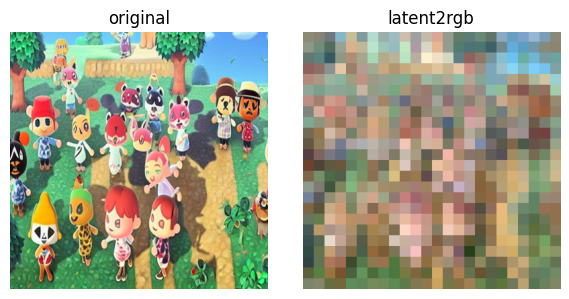

In [ ]:
IMAGE_PATH = 'experiments/animalcrossing.png'

img = Image.open(IMAGE_PATH).convert("RGB")

probe = nn.Linear(EMBED_DIM, 3).to(DEVICE)
probe.load_state_dict(torch.load("vjepa_latent2rgb_probe.pt", map_location=DEVICE, weights_only=True))
probe.eval()
print("✅ probe loaded")

with torch.no_grad():
    tensor = (
        normalize(img)
        .unsqueeze(0)
        .unsqueeze(2)
        .to(DEVICE)
        .float()
    )  # [1, 3, 1, 384, 384]

    emb = vjepa(tensor).squeeze(0)          # [576, 1024]
    pred = probe(emb.float()).cpu().numpy() # [576, 3]

    rgb = np.clip(pred, 0, 1).reshape(GRID, GRID, 3)

decoded = Image.fromarray((rgb * 255).astype(np.uint8)).resize((384, 384), Image.NEAREST)

# ---------- side-by-side ----------
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

axes[0].imshow(img.resize((384, 384)))
axes[0].set_title("original")
axes[0].axis("off")

axes[1].imshow(decoded)
axes[1].set_title("latent2rgb")
axes[1].axis("off")

plt.tight_layout()
plt.show()

# Video Probing

In [ ]:
VIDEO_PATH = "experiments/example1.mp4"

p = Path(VIDEO_PATH)
OUT_PATH = str(p.with_name(p.stem+"_latent2rgb"+p.suffix))

MAX_FRAMES = None
SIZE = 384

probe = nn.Linear(EMBED_DIM,3).to(DEVICE)
probe.load_state_dict(torch.load("vjepa_latent2rgb_probe.pt", map_location=DEVICE, weights_only=True))
probe.eval()
print("✅ probe loaded")

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened(): raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
limit = min(total,MAX_FRAMES) if MAX_FRAMES else total
print(f"🎞️ {total} frames @ {fps:.2f} FPS → processing {limit}")

workdir = Path(tempfile.mkdtemp(prefix="vjepa_video_"))
raw = workdir/"side_by_side.mp4"

ffmpeg = subprocess.Popen([
    "ffmpeg","-y",
    "-f","rawvideo","-vcodec","rawvideo",
    "-pix_fmt","rgb24","-s",f"{SIZE*2}x{SIZE}",
    "-r",str(fps),"-i","-",
    "-c:v","libx264","-preset","medium","-crf","18",
    "-pix_fmt","yuv420p",str(raw)
],stdin=subprocess.PIPE, stdout=subprocess.DEVNULL, stderr=subprocess.PIPE)

decode_time = 0.0  # accumulates time spent in embed + probe + RGB reconstruction
script_start = time.time()

with torch.no_grad():
    for i in range(limit):
        ok,bgr = cap.read()
        if not ok: break

        original = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)
        img = Image.fromarray(original)

        x = normalize(img).unsqueeze(0).unsqueeze(2).to(DEVICE).float()

        # --- decoding timer start ---
        decode_start = time.time()

        emb = vjepa(x).squeeze(0)
        pred = probe(emb.float()).cpu().numpy()

        rgb = np.clip(pred, 0, 1).reshape(GRID, GRID, 3)
        decoded = (rgb*255).astype(np.uint8)
        decoded = cv2.resize(decoded, (SIZE, SIZE), interpolation=cv2.INTER_NEAREST)

        if DEVICE == "cuda":
            torch.cuda.synchronize()  # ensure GPU work is actually finished before stopping the clock
        decode_time += time.time() - decode_start
        # --- decoding timer end ---

        original = cv2.resize(original, (SIZE, SIZE), interpolation=cv2.INTER_AREA)

        # Original | Latent → RGB
        combined = np.concatenate([original, decoded], axis=1)

        ffmpeg.stdin.write(combined.tobytes())

        if (i+1)%10==0 or i+1==limit:
            print(f"\r🧠 {i+1}/{limit} ({(i+1)/limit*100:.1f}%)",end="")

cap.release()
ffmpeg.stdin.close()

stderr=ffmpeg.stderr.read().decode(errors="replace")
if ffmpeg.wait()!=0: raise RuntimeError(stderr)

shutil.copy2(raw,OUT_PATH)
shutil.rmtree(workdir, ignore_errors=True)

total_elapsed = time.time() - script_start
frames_processed = i+1 if 'i' in dir() else 0
print(f"\nDecoding time: {decode_time:.2f}s "
      f"({decode_time/max(frames_processed,1)*1000:.1f} ms/frame)")
print(f"Total elapsed: {total_elapsed:.2f}s")
print(f"\nsaved to{OUT_PATH}")
display(Video(OUT_PATH, embed=True, width=768))

✅ probe loaded
🎞️ 40 frames @ 5.00 FPS → processing 40
🧠 40/40 (100.0%)
⏱️ Decoding time: 12.58s (314.6 ms/frame)
⏱️ Total elapsed: 14.12s

✅ saved → experiments\example1_latent2rgb.mp4
